In [ ]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

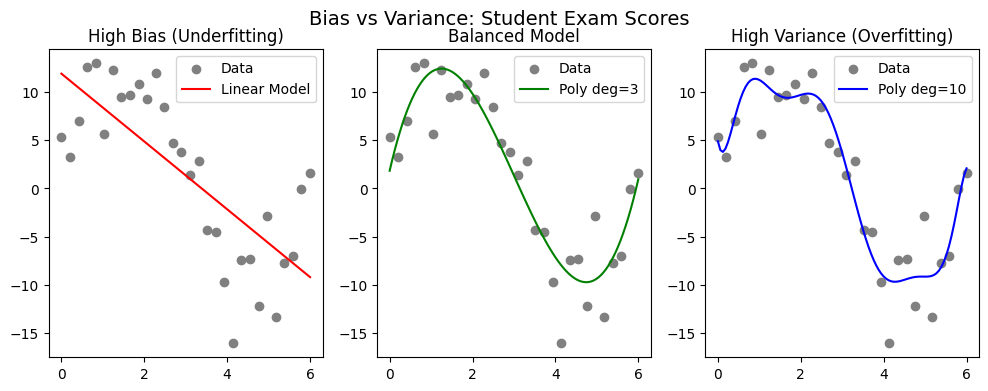

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- Step 1: Simulate dataset ---
# 30 students, study hours vs exam scores (with noise)
np.random.seed(0)
X = np.linspace(0, 6, 30).reshape(-1, 1)   # study hours
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30)  # exam scores with noise

# --- Step 2: Define models ---
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   # simple line
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())  # complex curve
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) # "just right"

# --- Step 3: Fit models ---
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

# --- Step 4: Predictions ---
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

# --- Step 5: Plot results ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

In [ ]:
# Scenario: Predicting Athlete Performance
# A sports academy wants to build a model to predict athlete sprint times (in seconds) based on training
#  hours. They collect data from 30 athletes, but the sprint times are noisy because of other factors (like diet, fatigue, or weather).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes sprint times improve perfectly with more
#  training hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts sprint times that are too fast or too slow compared
#  to actual results, what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new athletes, what does this show about variance?
# - Part C: Which model is likely to generalize better to new athletes, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance”
#  to a coach who doesn’t know machine learning?

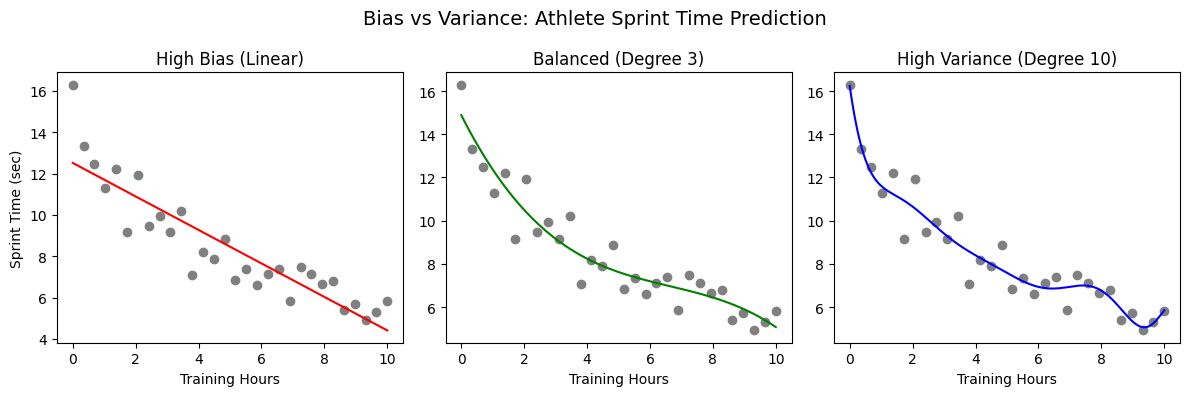

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# -------------------------------
# Step 1: Simulate Athlete Dataset
# -------------------------------

np.random.seed(1)

# Training hours (30 athletes)
X = np.linspace(0, 10, 30).reshape(-1, 1)

# True relationship:
# Sprint time decreases with training, but improvement slows over time
true_time = 15 - 4*np.log1p(X).ravel()

# Add noise (diet, fatigue, weather, etc.)
y = true_time + np.random.normal(scale=0.8, size=30)

# -------------------------------
# Step 2: Define Models
# -------------------------------

linear_model = make_pipeline(
    PolynomialFeatures(1, include_bias=False),
    LinearRegression()
)

balanced_model = make_pipeline(
    PolynomialFeatures(3, include_bias=False),
    LinearRegression()
)

complex_model = make_pipeline(
    PolynomialFeatures(10, include_bias=False),
    LinearRegression()
)

# -------------------------------
# Step 3: Fit Models
# -------------------------------

linear_model.fit(X, y)
balanced_model.fit(X, y)
complex_model.fit(X, y)

# -------------------------------
# Step 4: Predictions
# -------------------------------

X_plot = np.linspace(0, 10, 200).reshape(-1, 1)

y_linear = linear_model.predict(X_plot)
y_balanced = balanced_model.predict(X_plot)
y_complex = complex_model.predict(X_plot)

# -------------------------------
# Step 5: Plot Results
# -------------------------------

plt.figure(figsize=(12, 4))

# High Bias
plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray")
plt.plot(X_plot, y_linear, color="red")
plt.title("High Bias (Linear)")
plt.xlabel("Training Hours")
plt.ylabel("Sprint Time (sec)")

# Balanced
plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray")
plt.plot(X_plot, y_balanced, color="green")
plt.title("Balanced (Degree 3)")
plt.xlabel("Training Hours")

# High Variance
plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray")
plt.plot(X_plot, y_complex, color="blue")
plt.title("High Variance (Degree 10)")
plt.xlabel("Training Hours")

plt.suptitle("Bias vs Variance: Athlete Sprint Time Prediction", fontsize=14)
plt.tight_layout()
plt.show()